In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import yfinance as yf


In [2]:
df = yf.Ticker("TSLA").history(period="1y")

# Calculate 20-day moving average and standard deviation
df["SMA_20"] = df["Close"].rolling(window=20).mean()
df["STD_20"] = df["Close"].rolling(window=20).std()

# Calculate Bollinger Bands
df["Upper_Band"] = df["SMA_20"] + (df["STD_20"] * 2)
df["Lower_Band"] = df["SMA_20"] - (df["STD_20"] * 2)

# Band Width (indicates volatility)
df["Band_Width"] = df["Upper_Band"] - df["Lower_Band"]
df


,Open,High,Low,Close,Volume,Dividends,Stock Splits,SMA_20,STD_20,Upper_Band,Lower_Band,Band_Width
Date,,,,,,,,,,,,
2024-04-01 00:00:00-04:00,176.169998,176.750000,170.210007,175.220001,81562100,0.0,0.0,NaN,NaN,NaN,NaN,NaN
2024-04-02 00:00:00-04:00,164.750000,167.690002,163.429993,166.630005,116650600,0.0,0.0,NaN,NaN,NaN,NaN,NaN
2024-04-03 00:00:00-04:00,164.020004,168.820007,163.279999,168.380005,82950100,0.0,0.0,NaN,NaN,NaN,NaN,NaN
2024-04-04 00:00:00-04:00,170.070007,177.190002,168.009995,171.110001,123162000,0.0,0.0,NaN,NaN,NaN,NaN,NaN
2024-04-05 00:00:00-04:00,169.080002,170.860001,160.509995,164.899994,141250700,0.0,0.0,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
2025-03-24 00:00:00-04:00,258.079987,278.640015,256.329987,278.390015,169079900,0.0,0.0,259.223001,24.801236,308.825473,209.620529,99.204944
2025-03-25 00:00:00-04:00,283.600006,288.200012,271.279999,288.140015,150361500,0.0,0.0,258.490002,23.634741,305.759485,211.220520,94.538966
2025-03-26 00:00:00-04:00,282.660004,284.899994,266.510010,272.059998,153629800,0.0,0.0,257.553003,22.636800,302.826602,212.279404,90.547199


In [3]:
# Identify breakouts (price moving significantly above/below Bollinger Bands)
df["Breakout"] = ((df["Close"] > df["Upper_Band"]) | (df["Close"] < df["Lower_Band"])).astype(int)

# Identify consolidation (low Bollinger Band width)
df["Consolidation"] = (df["Band_Width"] < df["Band_Width"].rolling(window=10).mean() * 0.8).astype(int)

# Final Label: 1 for Breakout, 0 for Consolidation
df["Target"] = (df["Breakout"] == 1).astype(int)

In [4]:
# Select features
features = ["Band_Width", "Close", "Volume"]
X = df[features].dropna()
y = df["Target"].loc[X.index]  # Ensure matching index
print(len(X))
# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, train_size=0.8, random_state=42)

# Train a simple RandomForest classifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")

231
Accuracy: 0.85


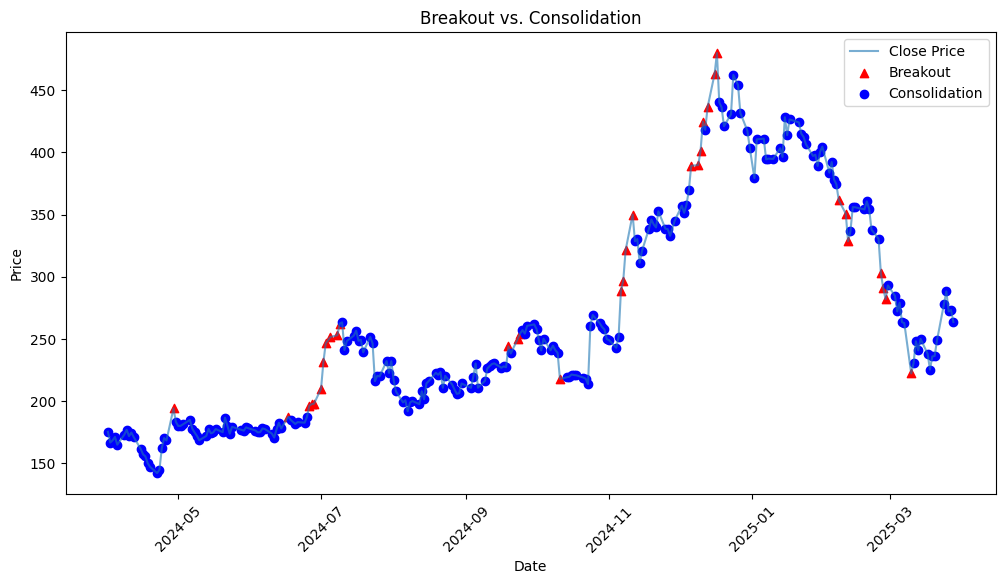

In [5]:
plt.figure(figsize=(12,6))

# Plot the close price
plt.plot(df.index, df["Close"], label="Close Price", alpha=0.6)

# Scatter plot for breakouts
plt.scatter(df.index[df["Target"] == 1], df["Close"][df["Target"] == 1],
            color="red", label="Breakout", marker="^")

# Scatter plot for consolidations
plt.scatter(df.index[df["Target"] == 0], df["Close"][df["Target"] == 0],
            color="blue", label="Consolidation", marker="o")

# Add labels and title
plt.legend()
plt.xlabel("Date")
plt.ylabel("Price")
plt.title("Breakout vs. Consolidation")

# Rotate x-axis labels for better visibility
plt.xticks(rotation=45)

plt.show()


In [12]:
import os
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

DATA_DIR = "data"

scaler = StandardScaler()

def extract_features(df):
    raw_features = df[["Open", "High", "Low", "Close", "Volume"]].copy()
    df["price_change"] = df["Close"] - df["Open"]
    df["body_size"] = abs(df["Close"] - df["Open"])
    df["wick_size"] = df["High"] - df["Low"]
    df["upper_wick"] = df["High"] - df[["Open", "Close"]].max(axis=1)
    df["lower_wick"] = df[["Open", "Close"]].min(axis=1) - df["Low"]
    df["volatility"] = df["High"] - df["Low"]
    feature_df = df.dropna().drop(["Open", "High", "Low", "Close", "Volume"], axis=1)
    raw_features_scaled = pd.DataFrame(scaler.fit_transform(raw_features), columns=raw_features.columns, index=raw_features.index)
    feature_df = pd.concat([raw_features_scaled, feature_df], axis=1)

    return feature_df

data = []
labels = []
max_length = 0

for trend in ["bearish", "bullish"]:  # Loop through main categories
    trend_path = os.path.join(DATA_DIR, trend)
    for pattern in os.listdir(trend_path):  # Loop through pattern types
        pattern_path = os.path.join(trend_path, pattern)
        if os.path.isdir(pattern_path):
            for file in os.listdir(pattern_path):
                file_path = os.path.join(pattern_path, file)
                df = pd.read_csv(file_path)
                features = extract_features(df)
                if not features.empty:
                    max_length = max(max_length, features.shape[0])

for trend in ["bearish", "bullish"]:
    trend_path = os.path.join(DATA_DIR, trend)
    for pattern in os.listdir(trend_path):
        pattern_path = os.path.join(trend_path, pattern)
        if os.path.isdir(pattern_path):
            for file in os.listdir(pattern_path):
                file_path = os.path.join(pattern_path, file)
                df = pd.read_csv(file_path)

                # Extract features
                features = extract_features(df)
                if not features.empty:
                    # Pad sequences to max_length
                    pad_size = max_length - features.shape[0]
                    features = np.pad(features, ((pad_size, 0), (0, 0)), mode="constant")

                    data.append(features.flatten())  # Flatten into a single row
                    labels.append(f"{trend}_{pattern}")

X = np.vstack(data)
y = np.array(labels)

# Scale features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

# Train model
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Evaluate
y_pred = clf.predict(X_test)
print(f'Trained on: {y_train}')
print(f'Real labels: {y_test}\nPredicted labels: {y_pred}')
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")


Trained on: ['bullish_base' 'bullish_flag' 'bullish_flag' 'bullish_flag'
 'bullish_base' 'bullish_flag' 'bearish_base' 'bullish_flag'
 'bullish_base' 'bullish_base' 'bullish_flag' 'bullish_flag'
 'bullish_base' 'bullish_base']
Real labels: ['bearish_base' 'bearish_base']
Predicted labels: ['bullish_base' 'bullish_flag']
Accuracy: 0.00
